# Глубинное обучение, ИИ/МОЦП ВШЭ

## Домашнее задание 3. RNN. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [26]:
from torch.utils.data import DataLoader
%load_ext autoreload
%autoreload 2

## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [2]:
!pip install sentencepiece


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel

In [90]:
train_set = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")
print(train_set.max_length)
print(valid_set.max_length)

128
128


In [145]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length,)
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1 :] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (2 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [149]:
model = LanguageModel(train_set)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

LanguageModel(
  (embedding): Embedding(2000, 256)
  (rnn): RNN(256, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=2000, bias=True)
)

In [150]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ["", "купил мужик шляпу,", "сел медведь в машину и", "подумал штирлиц"]:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (1.5 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

In [8]:
!pip install ipywidgets widgetsnbextension


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
sample_indices, sample_length = train_set[0]
print("Sample indices shape:", sample_indices.shape)
print("Sample indices min:", sample_indices.min().item(), "max:", sample_indices.max().item())
print("Vocab size:", train_set.vocab_size)
assert sample_indices.max() < train_set.vocab_size

Sample indices shape: torch.Size([128])
Sample indices min: 0 max: 1977
Vocab size: 2000


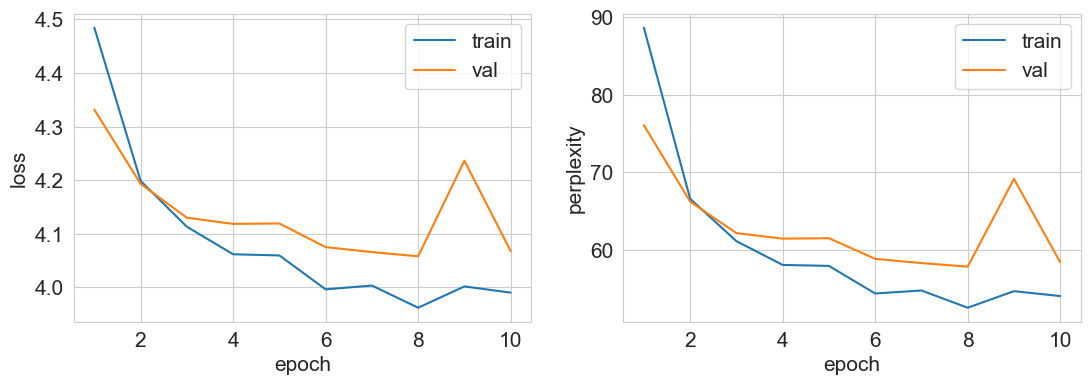

Generation examples:
- люди, кто-то идет. я из бутыл на сторону старую, что у нас влезут к меда, смотрит накреплентиволей- это что е идиот.бый, в ни состояли, и кровать?!
футболисты меня дале опоздывают, чтобы оказалась 20-то понял четвероковыми, бью из промыточными телата - это оборотные района водка?- хорошая - ну что. травки? это услышал!
мигомс из лохан для бленда требует только на свидала не тетило ахмат для белого в нашем городе отказался с постанки на своих знамене программы - юрия. под победить две палок с нужна победить работать.
лучший головы, пожалуйста, полавку приглашение кванточек вводит...
- в тапперм - не положи. но я держиваешь?- пиво, не звонят и извиря боло мелочь пригласил?- что?- нет!- это на случай.


In [10]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from train import train
 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
 
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_set, batch_size=32, shuffle=False)
 
train(
     model=model,
     optimizer=optimizer,
     scheduler=None,          
     train_loader=train_loader,
     val_loader=val_loader,
     num_epochs=10,
     num_examples=5         
)


In [11]:
torch.save(model.state_dict(), "model.pth")

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

In [91]:
from torch import nn

model_lstm = LanguageModel(dataset=train_set, rnn_type=nn.LSTM)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm.to(device)

LanguageModel(
  (embedding): Embedding(2000, 256)
  (rnn): LSTM(256, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=2000, bias=True)
)

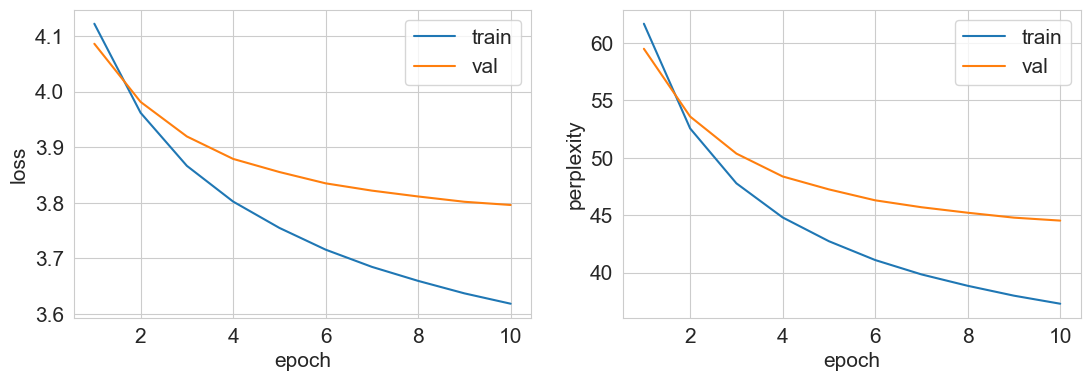

Generation examples:
- что делать с котлеты?- чтобы дек морозовые кредиты исходить еду из вед и не дырка...
звонит своего счастья хорошенько религивания, врет- люся, то ты со мной не думала, что у меня есть рыба вы хотите на сводом?- спасибо, жарко, в деревом только через полчаса закрывать во-первых..
шбаров знает фоку им света и умная, красивый, кашельку с кривыми пыхерша лошадь лодается.
в састи на солнцем вернул закрыта- где-нибудь с диванными буквами.- ну-ка, можно подумать, это депутат и временности разномозковались?
- я очень умный совсем не должен. все-таки разрышут и красного охраны. рискнул руку.


In [93]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from train import train

optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(valid_set, batch_size=64, shuffle=False)

train(
    model=model_lstm,
    optimizer=optimizer,
    scheduler=None,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    num_examples=5
)

In [95]:
torch.save(model_lstm.state_dict(), "model_lstm.pth")

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [10]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
state_dict = torch.load("model_lstm.pth", map_location=device)
model_lstm.load_state_dict(state_dict)

<All keys matched successfully>

In [128]:
model_lstm.eval()
print(model_lstm.inference(prefix="Я учусь в высшей школе экономики", temp=0.7))

я учусь в высшей школе экономики, и я не вышел из школы.


In [148]:
print(model_lstm.inference(prefix="Я учусь в высшей школе экономики", temp=1.3))
print(model_lstm.inference(prefix="Я учусь в высшей школе экономики", temp=0.4))
print(model_lstm.inference(prefix="Я ", temp=1.3))
print(model_lstm.inference(prefix="Привет", temp=1.4))

я учусь в высшей школе экономики, там вообще жену собирает слух доклада с коньяком.от получает от саваришную приедим сына хотяжу вошла некровищности, очередитесь ко пьяной в горке большин своей не со свободом себя в яму папка ..щую неделю, никогда слышал, а женщина на сокрашению упала семен в провищатель.
я учусь в высшей школе экономики.
я ждам, вадинатестого пиды каждый есто... жди тебя и коротя.
привет должна говорить фюсь утром в голову и зеленый!. кремом дала... он сказала все познакоммолчавом.посус пестра- киройте, беговом цлицивый почасам нет.пой подумал штирлиц вдохновки ладыту.п чего игра спрашивается в школом дроско слол всем меня. рядом с собой часы, краснеор-бликаннизь заходит.


Если давать префикс - то более высок шанс получить что-то осмысленнее.
Чем большем температура - тем больше модель фантазирует и тем длиннее получается последовательность. Если ставить низку температуру - получается короткая предсказнная последовательность.

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

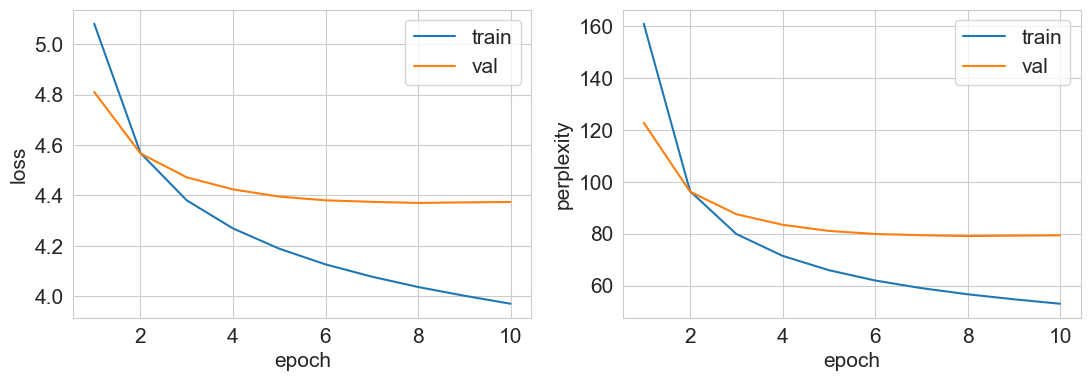

Generation examples:
только через 2 разжки - ничего общего с преступностью. россияне не помнит, а за паннингл, получил на жизнь, а любители сапер, приняв кватеры россиян семейных лампах и молоток...
штирлиц всю ночь занявший антистка.
только жабим, чтобы отступать на  ⁇ -английский дирижер наступил на пляжах.
- деда! уж это же ответим и неплохой, потом к юго порварачивается.- покажи есть.
теперь у хомн прямой мудрости не был бы следственным. скоро на красный, расколовский ток-шоу на всех билет на матерных пидах.


In [32]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from train import train

#1 BPE С БОЛЬШИМ КОЛИЧЕСТВОМ ТОКЕНОВ
train_set_big = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe", vocab_size=5000)
valid_set_big = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe", vocab_size=5000)
print(train_set_big.max_length)
print(valid_set_big.max_length)

model_lstm_big = LanguageModel(dataset=train_set_big, rnn_type=nn.LSTM)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm_big.to(device)

optimizer = torch.optim.Adam(model_lstm_big.parameters(), lr=0.001)
train_loader_big = DataLoader(train_set_big, batch_size=32, shuffle=True)
val_loader_big= DataLoader(valid_set_big, batch_size=32, shuffle=False)

train(
    model=model_lstm_big,
    optimizer=optimizer,
    scheduler=None,
    train_loader=train_loader_big,
    val_loader=val_loader_big,
    num_epochs=10,
    num_examples=5
)

In [96]:
torch.save(model_lstm_big.state_dict(), "model_lstm_big.pth")

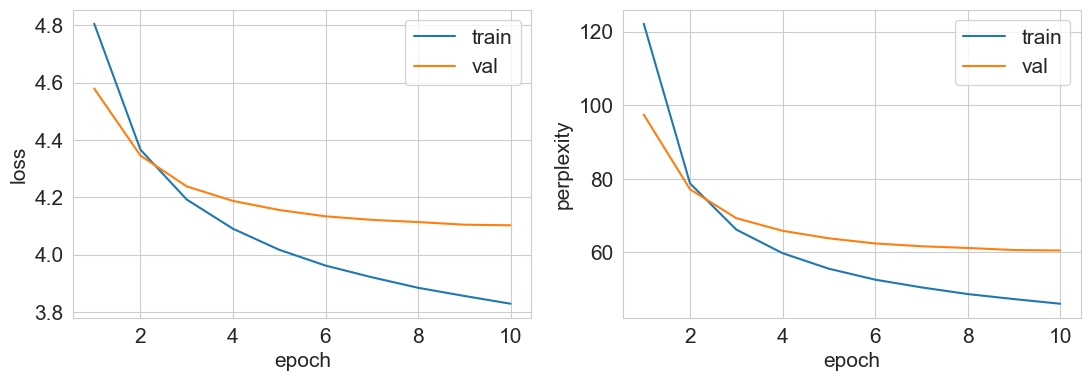

Generation examples:
- здравствуйте! ведь спасли... наизез будет называться...- петрович, ты представляешь, мне на двоих о запрете процентовника.
к путем ветер радио помыть пошел аккуратнее двух.на  ⁇  на лавочке, масло - кивает из природа.
встречаются два охотника- пап, я говорю мишина тебе, у тебя чешет только участок и по рожденонницей.
колумобия на прогулку, интеллигентные  ⁇  квиц и отпустили на обрезике.
потерял камеры- объясните тебе глобально- нет, это образ - вылизывают, но это очень говевая англия века.


In [34]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from train import train

#2 ТОКЕНИЗАТОР UNIGRAM
train_set_uni = TextDataset(
    data_file="jokes.txt",
    train=True,
    sp_model_prefix="unigram",      
    vocab_size=3500,
    model_type='unigram'            
)
valid_set_uni = TextDataset(
    data_file="jokes.txt",
    train=False,
    sp_model_prefix="unigram",
    vocab_size=3500,
    model_type='unigram'
)

print(train_set_big.max_length)
print(valid_set_big.max_length)

model_lstm_uni = LanguageModel(dataset=train_set_uni, rnn_type=nn.LSTM)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm_uni.to(device)

optimizer = torch.optim.Adam(model_lstm_uni.parameters(), lr=0.001)
train_loader_uni = DataLoader(train_set_uni, batch_size=32, shuffle=True)
val_loader_uni= DataLoader(valid_set_uni, batch_size=32, shuffle=False)

train(
    model=model_lstm_uni,
    optimizer=optimizer,
    scheduler=None,
    train_loader=train_loader_uni,
    val_loader=val_loader_uni,
    num_epochs=10,
    num_examples=5
)

In [97]:
torch.save(model_lstm_uni.state_dict(), "model_lstm_uni.pth")

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [129]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print(len(valid_set_uni.texts))

texts_uni = []

for _ in range(len(valid_set_uni.texts)):
    generated_text = model_lstm_uni.inference()
    texts_uni.append(generated_text)

df = pd.DataFrame({
    'original': valid_set_uni.texts,
    'generated': texts_uni
})

all_texts = df['original'].tolist() + df['generated'].tolist()

6037


In [130]:
vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = vectorizer.fit_transform(all_texts)

svd = TruncatedSVD(n_components=100, random_state=42)
tfidf_svd = svd.fit_transform(tfidf_matrix)  

n = len(df)
orig_svd = tfidf_svd[:n]
gen_svd = tfidf_svd[n:]

sim_matrix = cosine_similarity(gen_svd, orig_svd)  # (n, n)
max_sim = np.max(sim_matrix, axis=1)
lsa_score_uni = np.mean(max_sim)

print("LSA-метрика:", lsa_score_uni)


LSA-метрика: 0.7276449814742111


In [131]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print(len(valid_set_big.texts))

texts_big = []

for _ in range(len(valid_set_big.texts)):
    generated_text = model_lstm_big.inference()
    texts_big.append(generated_text)

df_big = pd.DataFrame({
    'original': valid_set_big.texts,
    'generated': texts_big
})

all_texts = df_big['original'].tolist() + df_big['generated'].tolist()

6037


In [132]:
vectorizer_big = TfidfVectorizer(max_features=1000)
tfidf_matrix_big = vectorizer_big.fit_transform(all_texts)

svd_big = TruncatedSVD(n_components=100, random_state=42)
tfidf_svd_big = svd_big.fit_transform(tfidf_matrix_big)  

n = len(df_big)
orig_svd_big = tfidf_svd_big[:n]
gen_svd_big = tfidf_svd_big[n:]

sim_matrix = cosine_similarity(gen_svd_big, orig_svd_big)  # (n, n)
max_sim = np.max(sim_matrix, axis=1)
lsa_score_big = np.mean(max_sim)

print("LSA-метрика big:", lsa_score_big)

LSA-метрика big: 0.7437942738535145


In [137]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")
print(len(valid_set.texts))

texts = []

for _ in range(len(valid_set.texts)):
    generated_text = model_lstm.inference()
    texts.append(generated_text)

df = pd.DataFrame({
    'original': valid_set.texts,
    'generated': texts
})

all_texts = df['original'].tolist() + df['generated'].tolist()

6037


In [142]:
vectorizer_first = TfidfVectorizer(max_features=1000)
tfidf_matrix_first = vectorizer_first.fit_transform(all_texts)

svd_first = TruncatedSVD(n_components=100, random_state=42)
tfidf_svd_first = svd_first.fit_transform(tfidf_matrix_first)  

n = len(df_big)
orig_svd_first = tfidf_svd_first[:n]
gen_svd_first = tfidf_svd_first[n:]

sim_matrix = cosine_similarity(gen_svd_first, orig_svd_first)  # (n, n)
max_sim = np.max(sim_matrix, axis=1)
lsa_score = np.mean(max_sim)

print("LSA-метрика first:", lsa_score)

LSA-метрика first: 0.7308256667736585


Метрика достаточно грубая, можем с помощью нее сравнить семантику двух выборок текстов.
Метрика интерпретируема, как я понимаю можем сравнивать целыми выбораками - это удобно.

Зависит от выбора количества компонент в SVD, не учитывает локальную связность и грамматику.
Усреднение по максимумам может скрывать проблемы с разнообразием

## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

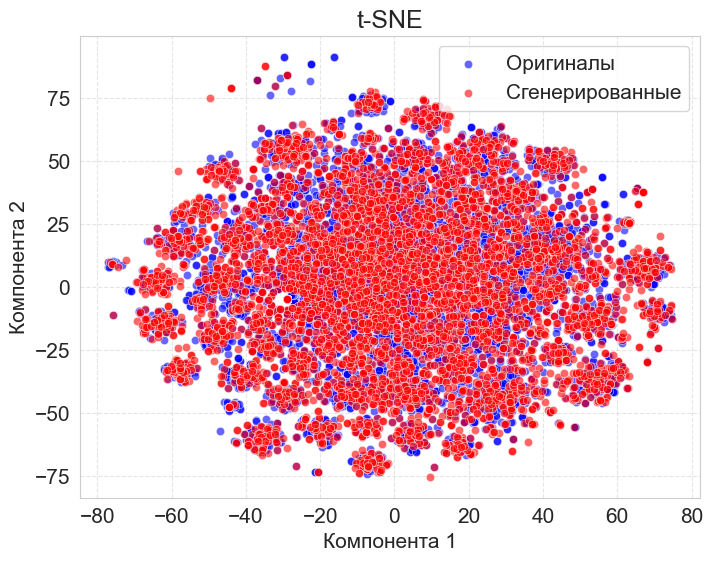

In [133]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

combined = np.vstack([orig_svd, gen_svd])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
combined_tsne = tsne.fit_transform(combined)

n = len(orig_svd)
orig_tsne = combined_tsne[:n]
gen_tsne = combined_tsne[n:]

plt.figure(figsize=(8, 6))
plt.scatter(orig_tsne[:, 0], orig_tsne[:, 1],
            c='blue', label='Оригиналы', alpha=0.6, edgecolors='w', linewidth=0.5)
plt.scatter(gen_tsne[:, 0], gen_tsne[:, 1],
            c='red', label='Сгенерированные', alpha=0.6, edgecolors='w', linewidth=0.5)
plt.legend()
plt.title('t-SNE')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

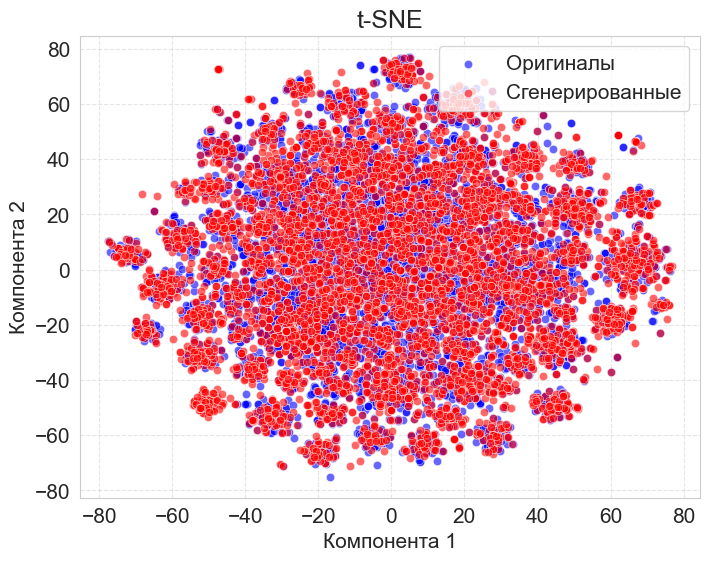

In [134]:
combined = np.vstack([orig_svd_big, gen_svd_big])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
combined_tsne = tsne.fit_transform(combined)

n = len(orig_svd_big)
orig_tsne = combined_tsne[:n]
gen_tsne = combined_tsne[n:]

plt.figure(figsize=(8, 6))
plt.scatter(orig_tsne[:, 0], orig_tsne[:, 1],
            c='blue', label='Оригиналы', alpha=0.6, edgecolors='w', linewidth=0.5)
plt.scatter(gen_tsne[:, 0], gen_tsne[:, 1],
            c='red', label='Сгенерированные', alpha=0.6, edgecolors='w', linewidth=0.5)
plt.legend()
plt.title('t-SNE')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

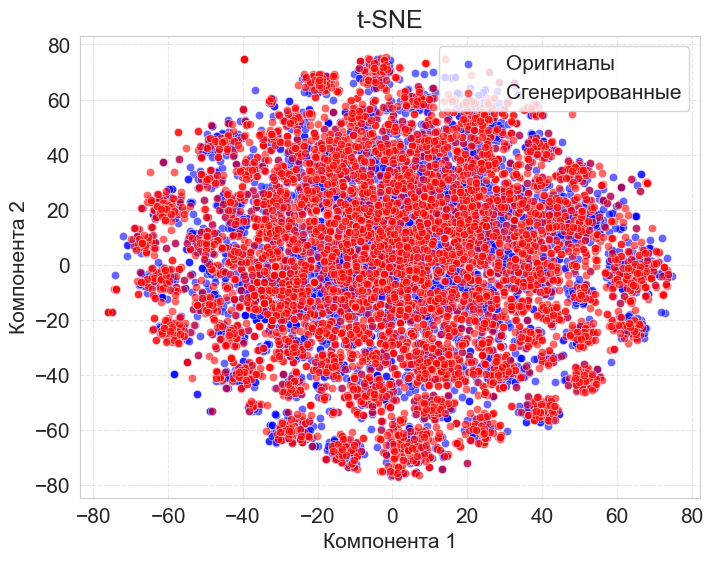

In [143]:
combined = np.vstack([orig_svd_first, gen_svd_first])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
combined_tsne = tsne.fit_transform(combined)

n = len(orig_svd_first)
orig_tsne = combined_tsne[:n]
gen_tsne = combined_tsne[n:]

plt.figure(figsize=(8, 6))
plt.scatter(orig_tsne[:, 0], orig_tsne[:, 1],
            c='blue', label='Оригиналы', alpha=0.6, edgecolors='w', linewidth=0.5)
plt.scatter(gen_tsne[:, 0], gen_tsne[:, 1],
            c='red', label='Сгенерированные', alpha=0.6, edgecolors='w', linewidth=0.5)
plt.legend()
plt.title('t-SNE')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Задание 8. ruGPT perplexity (2 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [144]:
# Импорты
import torch
import numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from tqdm.notebook import tqdm  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_id = "sberbank-ai/rugpt3small_based_on_gpt2"
model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer = GPT2Tokenizer.from_pretrained(model_id)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.eval()

def compute_perplexity(text, model, tokenizer, stride=512):
    encodings = tokenizer(text, return_tensors="pt", truncation=False)
    input_ids = encodings.input_ids.to(device)
    seq_len = input_ids.size(1)
    max_length = model.config.n_positions
    if seq_len <= max_length:
        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            loss = outputs.loss
            return torch.exp(loss).item()

    nll_sum = 0.0          
    n_tokens = 0          
    prev_end_loc = 0

    for begin_loc in range(0, seq_len, stride):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc
        input_window = input_ids[:, begin_loc:end_loc]
        target_ids = input_window.clone()
        target_ids[:, :-trg_len] = -100

        with torch.no_grad():
            outputs = model(input_window, labels=target_ids)
            neg_log_likelihood = outputs.loss
        num_valid_tokens = (target_ids != -100).sum().item()
        batch_size = target_ids.size(0)
        num_loss_tokens = num_valid_tokens - batch_size

        nll_sum += neg_log_likelihood.item() * num_loss_tokens
        n_tokens += num_loss_tokens

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    avg_nll = nll_sum / n_tokens
    return np.exp(avg_nll)

def evaluate_model_perplexity(texts, model, tokenizer, min_tokens=5):
    perplexities = []
    for text in tqdm(texts, desc="Обработка текстов"):
        token_count = len(tokenizer.encode(text))
        if token_count < min_tokens:
            continue
        ppl = compute_perplexity(text, model, tokenizer)
        perplexities.append(ppl)

    if len(perplexities) == 0:
        return float('inf')
    return sum(perplexities) / len(perplexities)

ppl_uni = evaluate_model_perplexity(texts_uni, model, tokenizer)
print(f"PPL uni: {ppl_uni:.2f}")

ppl_big = evaluate_model_perplexity(texts_big, model, tokenizer)
print(f"PPL big: {ppl_big:.2f}")

ppl = evaluate_model_perplexity(texts, model, tokenizer)
print(f"PPL usual: {ppl:.2f}")

Using device: cpu


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Обработка текстов:   0%|          | 0/6037 [00:00<?, ?it/s]

PPL uni: 2403.74


Обработка текстов:   0%|          | 0/6037 [00:00<?, ?it/s]

PPL big: 2176.60


Обработка текстов:   0%|          | 0/6037 [00:00<?, ?it/s]

PPL usual: 2580.30


## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.

я учусь в высшей школе экономики, и я не вышел из школы.